In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential 
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

tf.random.set_seed(1234)

In [22]:
X = np.load('./dataset/handsignX.npy')
y = np.load('./dataset/handsigny.npy')

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")




X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_cv: {X_cv.shape}")
print(f"Shape of y_test: {y_cv.shape}")

print(X_cv)

m,n = X.shape


# np.imshow(X)

Shape of X: (5000, 400)
Shape of y: (5000, 1)
Shape of X_train: (4000, 400)
Shape of y_train: (4000, 1)
Shape of X_cv: (1000, 400)
Shape of y_test: (1000, 1)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


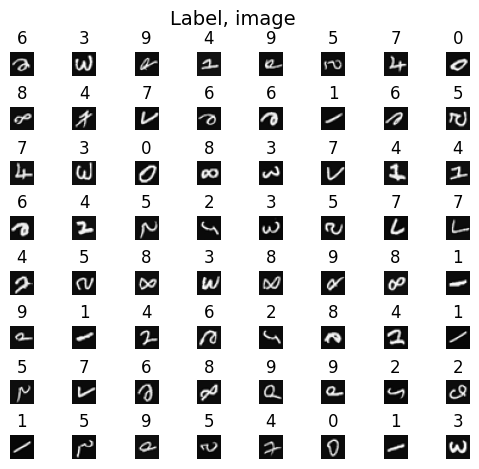

In [25]:
fig,axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

for i,ax in enumerate(axes.flat):
    rand_idx = np.random.randint(m)
    X_reshaped = X[rand_idx].reshape(20,20)
    ax.imshow(X_reshaped, cmap='grey')
    ax.set_title(y[rand_idx,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)



In [37]:


def nn_model(X_train, y_train, X_cv, y_cv, l_rate, regularizer, epoch):

    model = Sequential([
        Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(regularizer)),
        Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(regularizer)),
        Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(regularizer))
    ])

    # model.summary()
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer = tf.keras.optimizers.Adam(l_rate),
        metrics=['accuracy']
    )

    model.fit(X_train,y_train, epochs=epoch)
    print('\n')

    train_loss, train_acc = model.evaluate(X_train, y_train)
    cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
    print(f"Train Accuracy: {train_acc*100:.2f}")
    print(f"CV Accuracy: {cv_acc*100:.2f}")


In [39]:

regularizer = [0.01, 0.001,0.0001,0.0005]


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.01)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.01))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7820 - loss: 1.5086
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8397 - loss: 1.0961
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8472 - loss: 1.0573
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8508 - loss: 1.0380
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8568 - loss: 1.0133
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8568 - loss: 0.9995
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8608 - loss: 0.9823
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8625 - loss: 0.9727
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8640 - loss: 0.9657
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8660 - loss: 0.9612
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8670 - loss: 0.9547
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [28]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8048 - loss: 0.9278
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.4860
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9410 - loss: 0.4078
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.3643
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9638 - loss: 0.3370
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9697 - loss: 0.3140
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.2950
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9810 - loss: 0.2793
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9835 - loss: 0.2661
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9858 - loss: 0.2549
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9877 - loss: 0.2446
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [29]:


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8290 - loss: 0.5957
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9262 - loss: 0.3038
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9503 - loss: 0.2352
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9538 - loss: 0.2378
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9572 - loss: 0.2263
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9630 - loss: 0.2181
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9688 - loss: 0.2042
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9762 - loss: 0.1932
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.2405
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.2166
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9630 - loss: 0.2448
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [30]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0005)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0005)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0005))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7580 - loss: 1.0466
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9115 - loss: 0.4534
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9350 - loss: 0.3687
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9480 - loss: 0.3217
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9585 - loss: 0.2898
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9670 - loss: 0.2640
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9725 - loss: 0.2431
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9760 - loss: 0.2270
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9808 - loss: 0.2139
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9843 - loss: 0.2034
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9872 - loss: 0.1947
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

### Below I have provided and retrained the finalized model
*  Train Accuracy: 98.25%

*  CV Accuracy: 92.60%

*  The Gap: Just 5.65%

In [31]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8035 - loss: 0.9321
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9150 - loss: 0.4884
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9360 - loss: 0.4129
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9540 - loss: 0.3699
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9625 - loss: 0.3379
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9693 - loss: 0.3148
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9745 - loss: 0.2951
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9800 - loss: 0.2779
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9843 - loss: 0.2640
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9880 - loss: 0.2536
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9895 - loss: 0.2462
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [13]:
X_test = np.load('./dataset/testdata/dataset.npy')
y_test = np.load('./dataset/testdata/labels.npy')

# X_test = X_test[:, :2]
m = X_test.shape[0]

print(X_test.shape)
print(y_test.shape)


(104, 64, 64)
(104,)


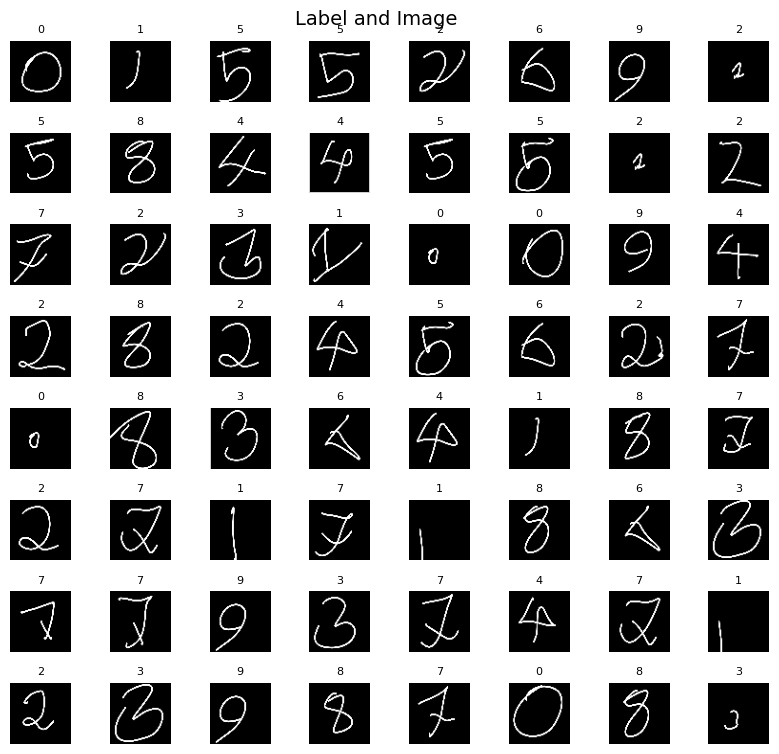

In [18]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.95])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test))

    ax.imshow(X_test[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Label and Image", fontsize=14)
plt.show()

In [23]:
from skimage.transform import resize

# X_test has shape (104, 64, 64)

X_test_resized = np.array([
    resize(img, (20, 20), anti_aliasing=True, preserve_range=True)
    for img in X_test
])


X_test_resized = X_test_resized.astype(np.float64)

if X_test_resized.max() > 1:
    X_test_resized /= 255.0

print(X_test_resized.shape)

(104, 20, 20)


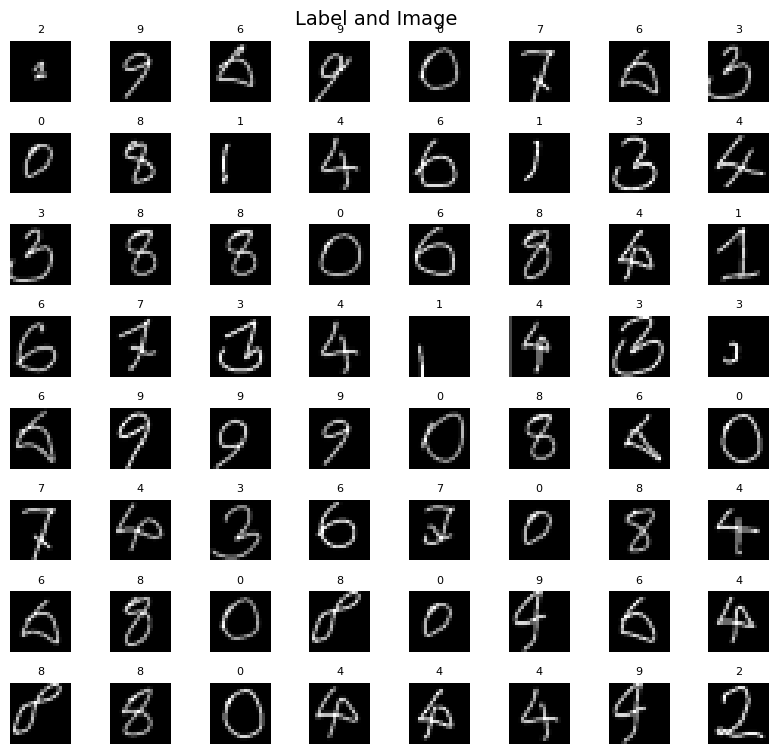

In [24]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.95])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test))

    ax.imshow(X_test_resized[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Label and Image", fontsize=14)
plt.show()

In [33]:
X_test_resized = X_test_resized.reshape(-1, 400)
logits = model.predict(X_test_resized)
predictions = np.argmax(logits, axis=1)

print(predictions)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[2 8 5 5 5 9 3 0 5 5 8 6 4 5 7 5 3 5 3 2 2 3 7 2 3 8 3 3 6 6 2 2 5 6 2 3 3
 5 8 8 8 8 5 8 8 3 3 9 8 8 3 9 8 3 7 7 3 3 3 3 8 3 5 5 5 6 5 5 5 5 9 5 8 8
 6 2 4 8 8 8 2 8 8 8 8 8 8 8 7 0 8 5 3 5 8 8 3 8 8 8 8 5 3 8]


In [34]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_resized, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy: {test_acc*100:.2f}")



125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9825 - loss: 0.2406
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9260 - loss: 0.4254
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1346 - loss: 3.5317 
Train Accuracy: 98.25
CV Accuracy: 92.60
Test Accuracy: 13.46


In [35]:
print(X_train.min(), X_train.max())
print(X_test_resized.min(), X_test_resized.max())

logits = model.predict(X_test_resized)
pred = np.argmax(logits, axis=1)

print(np.unique(pred, return_counts=True))
print(pred[:20])
print(y_test[:20])

-0.11993388483543918 1.127688299158888
0.10196078568696976 0.9138637185096741
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
(array([0, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 2,  9, 21,  2, 22,  6,  5, 33,  4]))
[2 8 5 5 5 9 3 0 5 5 8 6 4 5 7 5 3 5 3 2]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2]


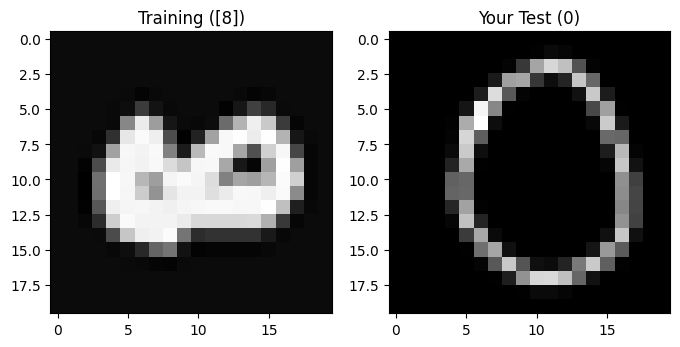

In [36]:
plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(X_train[0].reshape(20,20), cmap='gray')
plt.title(f"Training ({y_train[0]})")

plt.subplot(122)
plt.imshow(X_test_resized[0].reshape(20,20), cmap='gray')
plt.title(f"Your Test ({y_test[0]})")

plt.show()

In [37]:
from skimage.transform import resize
import numpy as np

X_test_processed = []

for img in X_test:
    # resize
    img = resize(img, (20,20), preserve_range=True)

    # normalize
    img = img / img.max()

    # threshold
    img = (img > 0.35).astype(np.float32)

    X_test_processed.append(img)

X_test_processed = np.array(X_test_processed).reshape(-1,400)


from scipy.ndimage import binary_dilation

X_test_processed = []

for img in X_test:
    img = resize(img, (20,20), preserve_range=True)
    img = img / img.max()
    img = img > 0.35

    img = binary_dilation(img, iterations=1)

    X_test_processed.append(img.astype(np.float32))

X_test_processed = np.array(X_test_processed).reshape(-1,400)

In [38]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_processed, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy: {test_acc*100:.2f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9825 - loss: 0.2406
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9260 - loss: 0.4254
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1442 - loss: 7.8776
Train Accuracy: 98.25
CV Accuracy: 92.60
Test Accuracy: 14.42
